# 1. Tech Challenge - Objetivo

**Contexto de negócio:** este projeto foi desenvolvido para um hospital que deseja um modelo de Machine Learning capaz de prever o nível de obesidade de um paciente a partir de hábitos alimentares, atividade física e dados antropométricos, apoiando a equipe médica na priorização de cuidado e orientação preventiva.

**Atenção metodológica:** o alvo (`Obesity`) é derivado do dataset público *Estimation of obesity levels* (UCI), cujo rótulo original é calculado a partir de faixas de IMC (peso / altura²). `Height` e `Weight` (e, por extensão, o próprio IMC) podem determinar quase completamente o alvo — por isso as novas features desta versão foram desenhadas para capturar hábito e comportamento, não para recombinar `Height`/`Weight`, evitando reforçar essa circularidade.

## 2. Importação das bibliotecas

In [1]:

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 3. Configurações iniciais

Definimos aqui o caminho do dataset bruto, a semente, a ordem lógica (do menor para o maior nível de obesidade) usada em todos os gráficos que envolvem a variável alvo, e configurações de exibição/estilo para manter os gráficos consistentes ao longo do notebook.

In [2]:
SEED = 42
CAMINHO_DADOS_BRUTOS = "../data/raw/obesity.csv"

ORDEM_NIVEIS_OBESIDADE = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

COLUNAS_NUMERICAS = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
COLUNAS_ORDINAIS_ARREDONDAR = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")
np.random.seed(SEED)

## 4. Leitura dos dados

In [16]:
pacientes_obesidade = pd.read_csv(CAMINHO_DADOS_BRUTOS)

pacientes_obesidade.shape

(2111, 17)

In [17]:
pacientes_obesidade.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 5. Análise exploratória

### 5.1 Tipos de dados, valores nulos e duplicatas

Sobre os 24 duplicados: serão removidos porque os valores contínuos nessas linhas não têm o ruído decimal característico do resto da base, indicando registro repetido e não paciente distinto. Além disso, é só 1,14% da base, então o impacto no modelo é pequeno de qualquer jeito; mas manter esses duplicados infla artificialmente o peso de algumas combinações específicas de hábito/perfil sem agregar sinal novo.

In [4]:
pacientes_obesidade.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   str    
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   str    
 5   FAVC            2111 non-null   str    
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   str    
 9   SMOKE           2111 non-null   str    
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   str    
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   str    
 15  MTRANS          2111 non-null   str    
 16  Obesity         2111 non-null   str    
dtypes: float64(8), str(9)
memory usage: 414.2 KB

In [19]:
quantidade_nulos = pacientes_obesidade.isna().sum()
quantidade_nulos

Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

In [22]:
quantidade_duplicatas = pacientes_obesidade.duplicated().sum()

print(f"Quantidade duplicadas: {quantidade_duplicatas}")
print(f"Pct duplicadas: {quantidade_duplicatas / len(pacientes_obesidade) * 100:.2f}%")

Quantidade duplicadas: 24
Pct duplicadas: 1.14%


In [ ]:
duplicadas = pacientes_obesidade[pacientes_obesidade.duplicated(keep=False)]
duplicadas

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
105,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
145,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
208,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight


### 5.2 Estatísticas descritivas — Age, Height e Weight

Essas três variáveis são a base do IMC e merecem um olhar dedicado antes das demais numéricas. Aqui já percebemos uma discrepância na amostra dos dados de Idade, com 75% da base tendo até 26 anos.

In [24]:
pacientes_obesidade[["Age", "Height", "Weight"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00


### 5.3 Distribuição da variável alvo (Obesity)

Checamos aqui se as classes de obesidade estão balanceadas — isso impacta diretamente a escolha de métricas e da estratégia de validação (split estratificado, F1-macro em vez de apenas accuracy).
É uma base relativamente balanceada. No entanto, como vamos deployar o modelo, e a base pode mudar com o tempo/versões, também vamos balancear as quantidades na etapa de modelagem.

In [8]:
distribuicao_alvo = pacientes_obesidade["Obesity"].value_counts().reindex(ORDEM_NIVEIS_OBESIDADE)
percentual_alvo = (distribuicao_alvo / len(pacientes_obesidade) * 100).round(2)

pd.DataFrame({"qtd_pacientes": distribuicao_alvo, "percentual": percentual_alvo})

,qtd_pacientes,percentual
Obesity,,
Insufficient_Weight,272,12.88
Normal_Weight,287,13.60
Overweight_Level_I,290,13.74
Overweight_Level_II,290,13.74
Obesity_Type_I,351,16.63
Obesity_Type_II,297,14.07
Obesity_Type_III,324,15.35


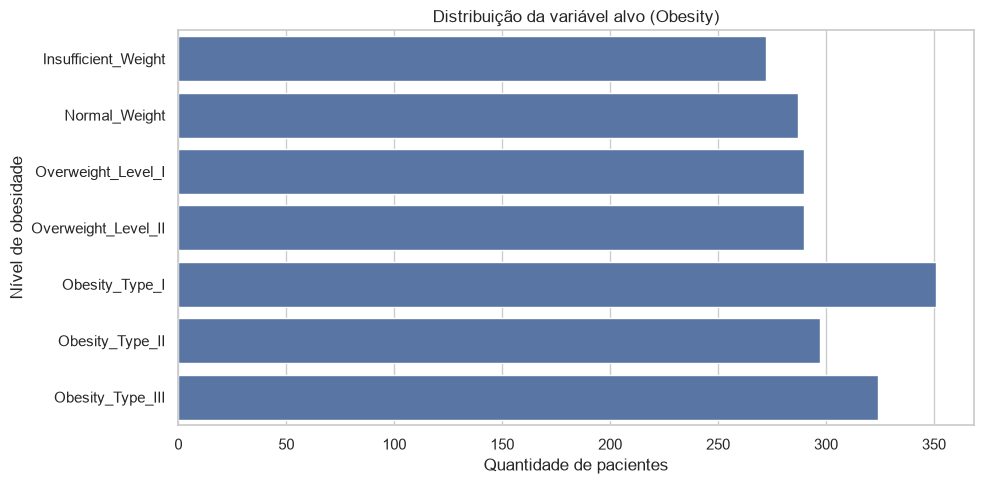

In [9]:
fig, eixo = plt.subplots(figsize=(10, 5))
sns.barplot(x=distribuicao_alvo.values, y=distribuicao_alvo.index, order=ORDEM_NIVEIS_OBESIDADE, ax=eixo)
eixo.set_title("Distribuição da variável alvo (Obesity)")
eixo.set_xlabel("Quantidade de pacientes")
eixo.set_ylabel("Nível de obesidade")
plt.tight_layout()
plt.show()

### 5.4 Histogramas das variáveis numéricas

Olhamos a forma da distribuição de cada variável numérica. Os ruídos decimais das colunas `FCVC`, `NCP`, `CH2O`, `FAF` e `TUE` serão tratados na seção de Limpeza. Além disso, novamente vemos que a base não trouxe uma amostra balanceada da idade (ela forma uma cauda, então, mais que outlier, está desbalanceado mesmo).

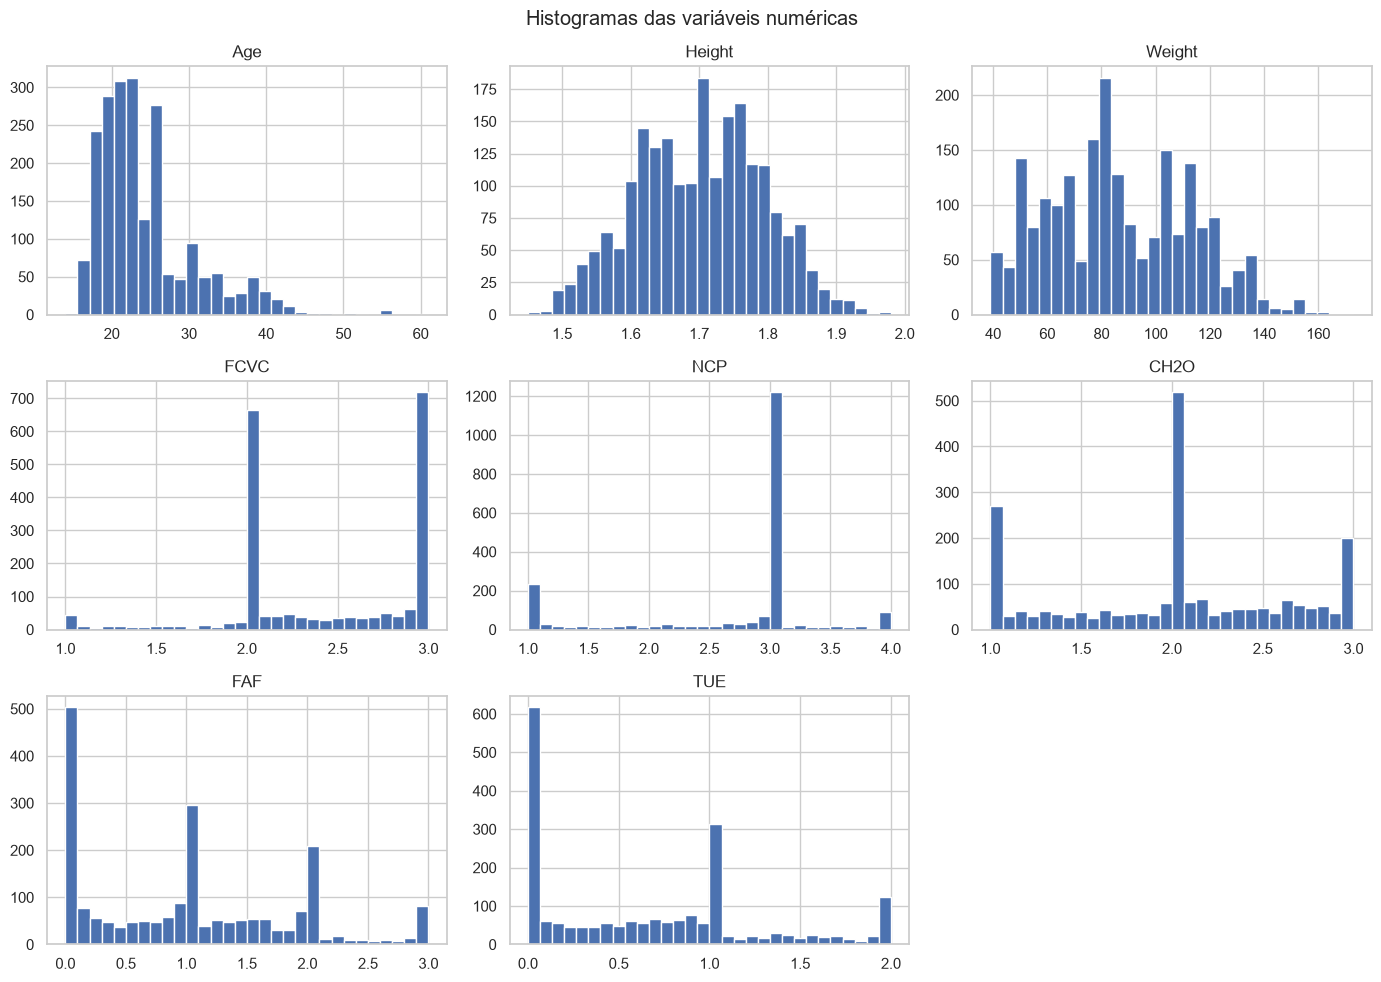

In [10]:
pacientes_obesidade[COLUNAS_NUMERICAS].hist(figsize=(14, 10), bins=30)
plt.suptitle("Histogramas das variáveis numéricas")
plt.tight_layout()
plt.show()

### 5.5 Boxplots das variáveis numéricas

Usados para identificar outliers e comparar a dispersão entre as variáveis. Optamos por não mexer nos outliers de idade, peso e altura, visto que a variedade é importante para a análise hospitalar. As outras variáveis são categóricas, dispensado o controle de outliers.

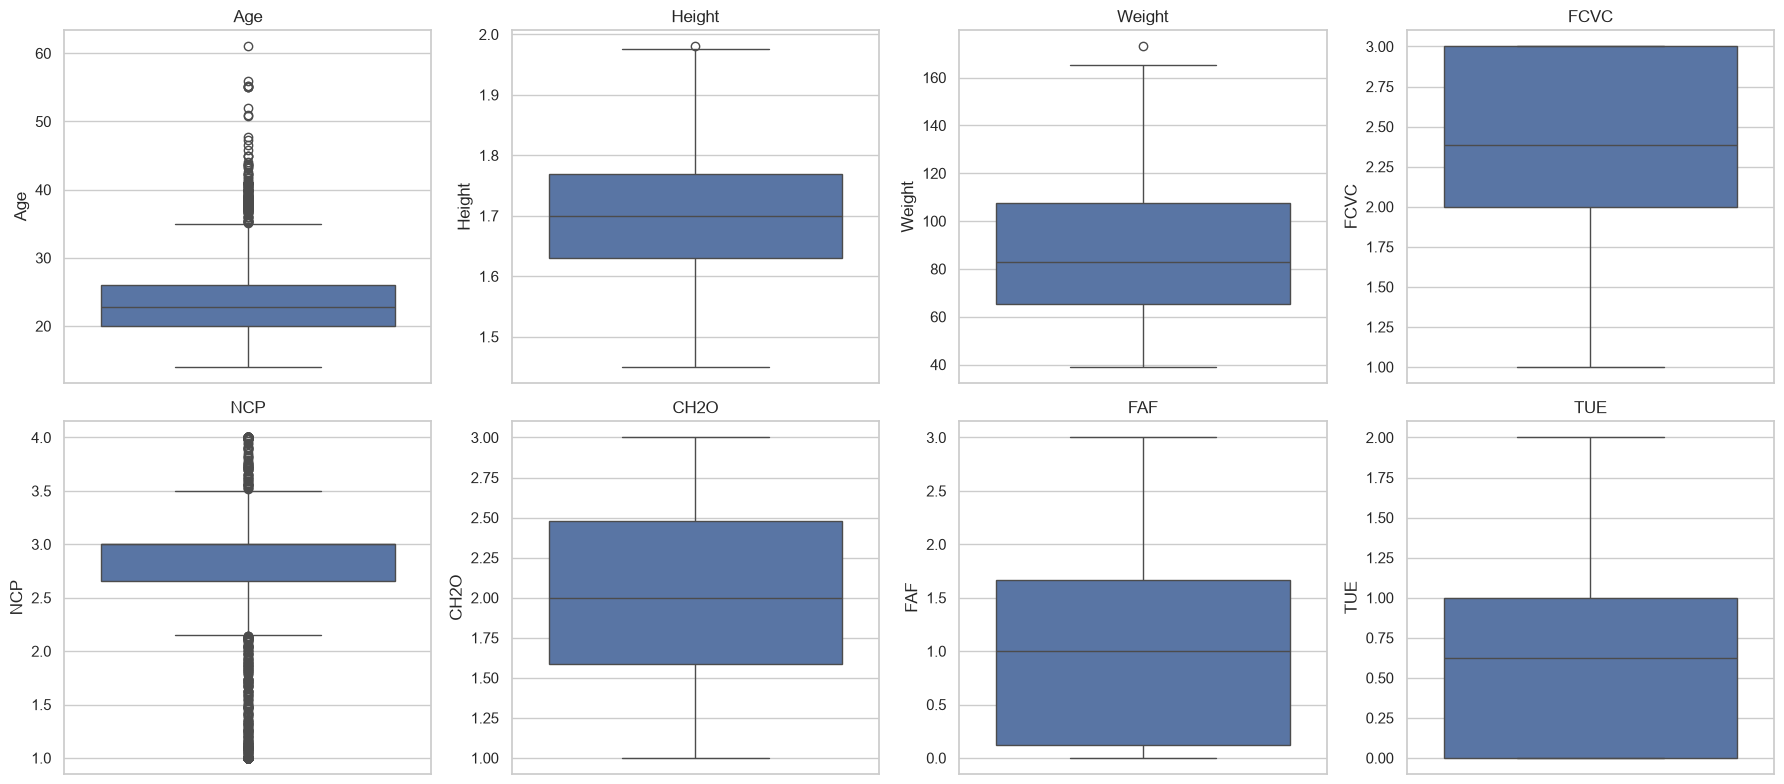

In [11]:
fig, eixos = plt.subplots(2, 4, figsize=(18, 8))
eixos = eixos.flatten()

for eixo, coluna in zip(eixos, COLUNAS_NUMERICAS):
    sns.boxplot(y=pacientes_obesidade[coluna], ax=eixo)
    eixo.set_title(coluna)

plt.tight_layout()
plt.show()

### 5.6 Matriz de correlação

Correlação de Pearson entre as variáveis numéricas, para identificar relações lineares fortes e possível multicolinearidade antes da modelagem.

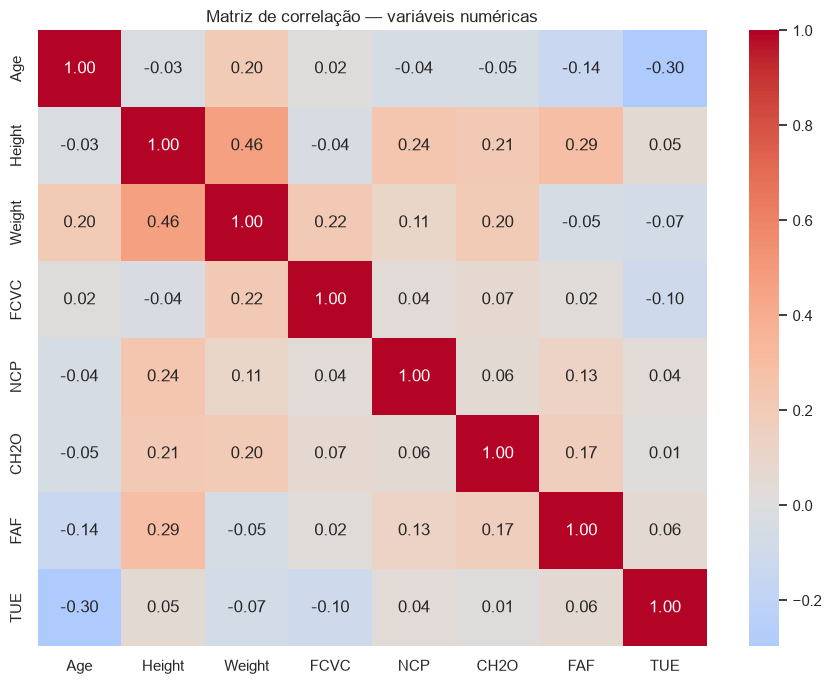

In [28]:
matriz_correlacao = pacientes_obesidade[COLUNAS_NUMERICAS].corr()

fig, eixo = plt.subplots(figsize=(9, 7))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=eixo)
eixo.set_title("Matriz de correlação — variáveis numéricas")
plt.tight_layout()
plt.show()

## 6. Limpeza dos dados

Aqui tratamos os dois problemas de qualidade identificados na seção anterior (duplicatas exatas e ruído decimal nas variáveis ordinais) e, com os dados já tratados, avançamos para o cruzamento das variáveis de hábito.

### 6.1 Remoção de duplicatas exatas

In [31]:
pacientes_sem_duplicatas = pacientes_obesidade.drop_duplicates().reset_index(drop=True)
len(pacientes_sem_duplicatas)

2087

In [32]:
pacientes_tratados = pacientes_sem_duplicatas.copy()
pacientes_tratados[COLUNAS_ORDINAIS_ARREDONDAR] = (
    pacientes_tratados[COLUNAS_ORDINAIS_ARREDONDAR].round().astype(int)
)

pacientes_tratados[COLUNAS_ORDINAIS_ARREDONDAR].describe()

,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,2.425970,2.703402,2.011500,1.009104,0.669861
std,0.585177,0.797108,0.685322,0.898712,0.673970
min,1.000000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,3.000000,2.000000,0.000000,0.000000
50%,2.000000,3.000000,2.000000,1.000000,1.000000
75%,3.000000,3.000000,2.000000,2.000000,1.000000
max,3.000000,4.000000,3.000000,3.000000,2.000000


### 6.3 Cruzamento das variáveis de hábito com a variável alvo

Analisamos como `FAVC`, `FCVC`, `FAF`, `CALC` e `MTRANS` se relacionam com o nível de obesidade. As categóricas (`FAVC`, `CALC`, `MTRANS`) são vistas via percentual de cada nível de obesidade dentro de cada categoria de hábito; as ordinais (`FCVC`, `FAF`, já arredondadas) via boxplot por classe.

Principais leituras do cruzamento:

- FAVC é o categórico com o gradiente mais limpo: entre quem responde "no", 52,7% está em Insufficient_Weight/Normal_Weight e só 7,8% nas três classes de Obesity_Type_*; entre quem responde "yes", essa proporção se inverte (51,6% nas classes de obesidade). 
- CALC não mostra um padrão monotônico (no tem mais casos em Obesity_Type_I do que Sometimes na mesma classe) e deve ser lido com cautela: a categoria Always tem apenas 1 paciente na base inteira e Frequently tem só 70 — os percentuais dessas categorias não são estatisticamente confiáveis e não devem ser tratados como tendência populacional.
- MTRANS: Walking e Bike concentram ~56-57% dos casos em Normal_Weight. Mas Bike (n=7) e Motorbike (n=11) têm amostras pequenas demais para generalizar.
- FAF tem gradiente monotônico claro, como o FAVC.
- FCVC, por outro lado, tem relação em U: mediana 3 tanto em Insufficient_Weight quanto em Obesity_Type_III (os dois extremos), caindo para 2 nas classes intermediárias.

Implicação para a modelagem: categorias com poucas observações (CALC == "Always", MTRANS in ["Bike", "Motorbike"]) merecem atenção no encoding (ex: agrupar com categorias vizinhas), para evitar que o modelo memorize ruído amostral.

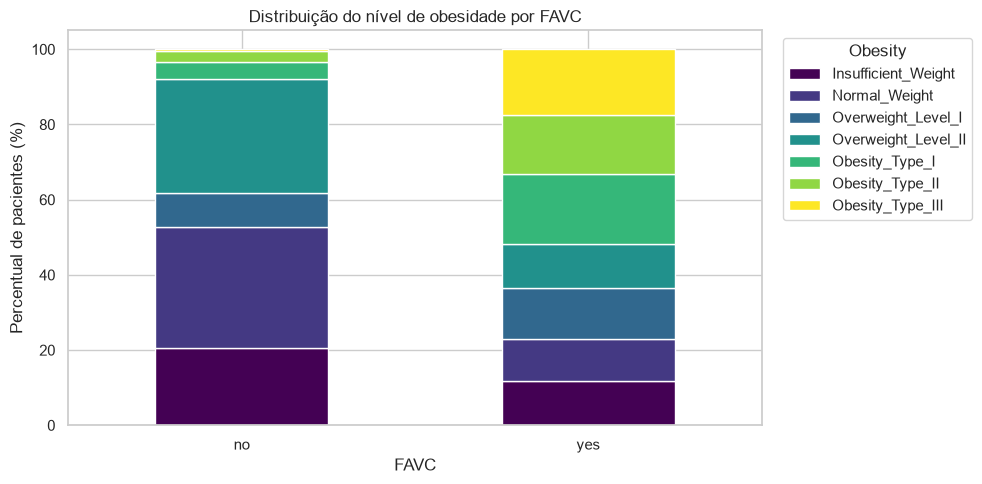

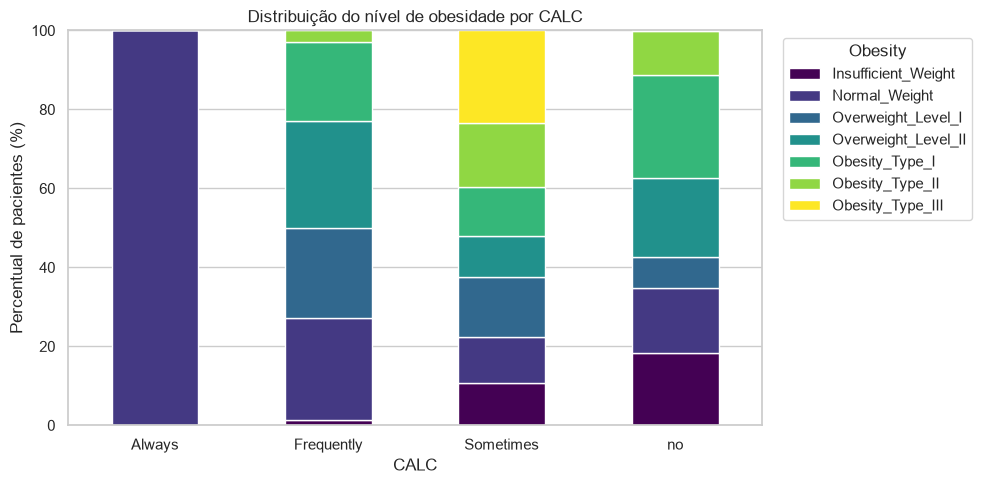

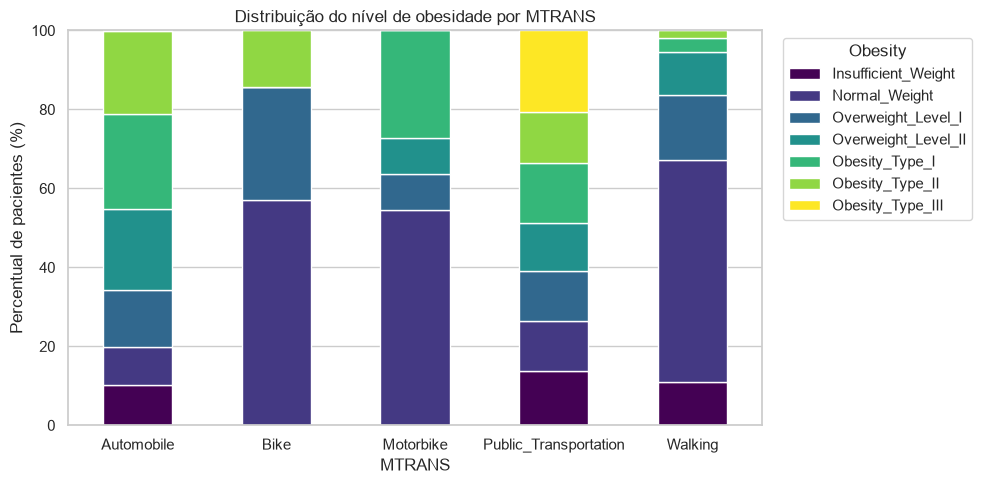

In [15]:
variaveis_habito_categoricas = ["FAVC", "CALC", "MTRANS"]

for coluna in variaveis_habito_categoricas:
    tabela_cruzada = (
        pd.crosstab(pacientes_tratados[coluna], pacientes_tratados["Obesity"], normalize="index")
        .reindex(columns=ORDEM_NIVEIS_OBESIDADE)
        * 100
    )

    tabela_cruzada.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="viridis")
    plt.title(f"Distribuição do nível de obesidade por {coluna}")
    plt.ylabel("Percentual de pacientes (%)")
    plt.xlabel(coluna)
    plt.xticks(rotation=0)
    plt.legend(title="Obesity", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

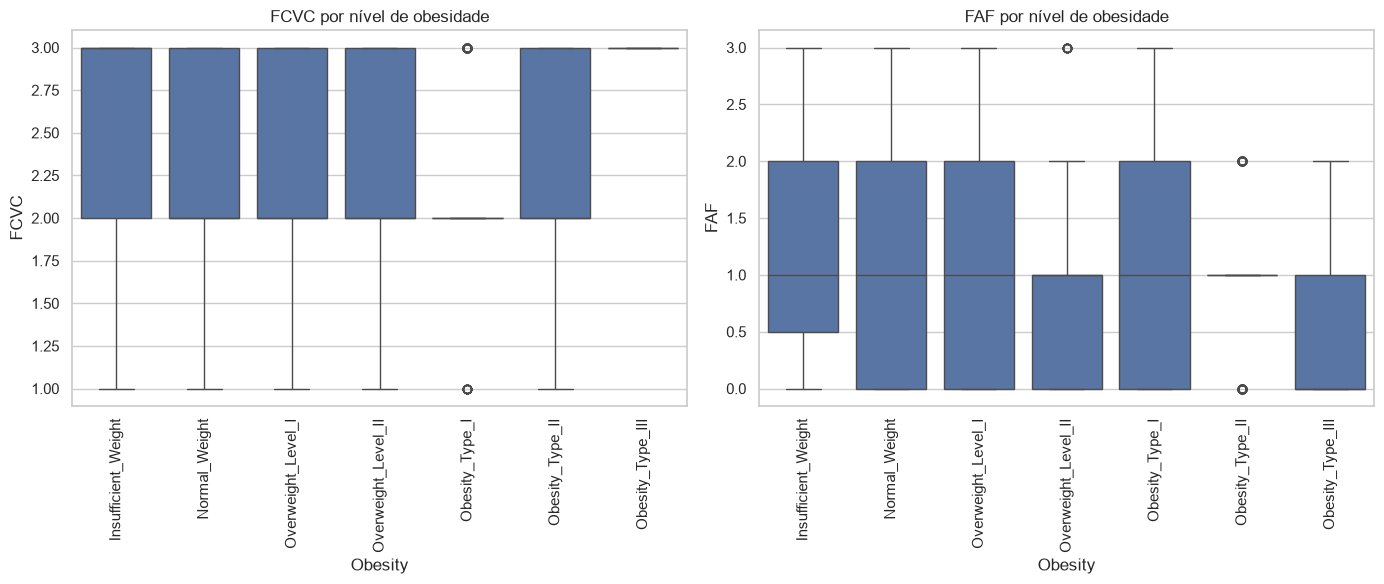

In [16]:
variaveis_habito_ordinais = ["FCVC", "FAF"]

fig, eixos = plt.subplots(1, 2, figsize=(14, 6))

for eixo, coluna in zip(eixos, variaveis_habito_ordinais):
    sns.boxplot(data=pacientes_tratados, x="Obesity", y=coluna, order=ORDEM_NIVEIS_OBESIDADE, ax=eixo)
    eixo.set_title(f"{coluna} por nível de obesidade")
    eixo.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## 7. Engenharia de atributos

### 7.1 IMC — verificação diagnóstica da derivação do alvo

Como o alvo deste dataset público (UCI *Estimation of obesity levels*) é conhecido por ser derivado de faixas de IMC, calculamos o IMC diretamente a partir de `Height` e `Weight` e comparamos com as classes de `Obesity` para confirmar essa hipótese antes da modelagem. Percebe-se que realmente há uma relação proporcional entre elas.

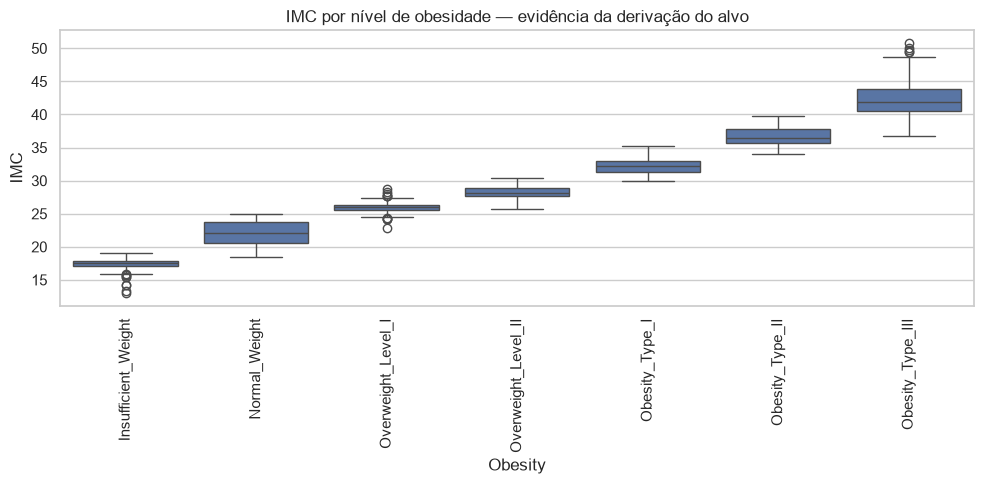

In [33]:
pacientes_tratados["IMC"] = pacientes_tratados["Weight"] / (pacientes_tratados["Height"] ** 2)

fig, eixo = plt.subplots(figsize=(10, 5))
sns.boxplot(data=pacientes_tratados, x="Obesity", y="IMC", order=ORDEM_NIVEIS_OBESIDADE, ax=eixo)
eixo.set_title("IMC por nível de obesidade — evidência da derivação do alvo")
eixo.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

In [35]:
faixas_imc_por_classe = (
    pacientes_tratados.groupby("Obesity")["IMC"].agg(["min", "max", "mean"]).reindex(ORDEM_NIVEIS_OBESIDADE)
)
faixas_imc_por_classe

,min,max,mean
Obesity,,,
Insufficient_Weight,12.998685,19.082206,17.390730
Normal_Weight,18.491124,24.913495,22.007841
Overweight_Level_I,22.826739,28.769607,25.956179
Overweight_Level_II,25.713513,30.362877,28.215232
Obesity_Type_I,29.911958,35.171095,32.255636
Obesity_Type_II,34.048509,39.786652,36.723424
Obesity_Type_III,36.774400,50.811753,42.273746


### 7.2 Novas features comportamentais

Todas construídas a partir de variáveis de hábito, comportamento e demografia — nenhuma delas usa `Height`, `Weight` ou o IMC calculado acima, justamente para o modelo prever de acordo com os padrões de vida dos pacientes, em vez de apenas replicar um cálculo IMC (e chegar a uma acurácia alta, mas vazia).

#### 7.2.1 `transporte_ativo`

Binária: 1 se o meio de transporte habitual (`MTRANS`) for `Walking` ou `Bike`, 0 caso contrário. Resume o sinal mais relevante de `MTRANS` (deslocamento ativo vs. passivo) em uma única variável.

In [36]:
pacientes_tratados["transporte_ativo"] = pacientes_tratados["MTRANS"].isin(["Walking", "Bike"]).astype(int)

(pacientes_tratados.groupby("Obesity")["transporte_ativo"].mean().reindex(ORDEM_NIVEIS_OBESIDADE) * 100).rename(
    "percentual_transporte_ativo"
)

Obesity
Insufficient_Weight     2.247191
Normal_Weight          12.411348
Overweight_Level_I      3.985507
Overweight_Level_II     2.068966
Obesity_Type_I          0.569801
Obesity_Type_II         0.673401
Obesity_Type_III        0.000000
Name: percentual_transporte_ativo, dtype: float64

#### 7.2.2 `score_risco_comportamental`

Contagem (0 a 9) de fatores de risco comportamentais presentes no paciente: histórico familiar, consumo calórico frequente, tabagismo, não monitorar calorias, comer entre as refeições com frequência, consumo de álcool frequente, baixa atividade física, alto tempo de tela e transporte passivo. Quanto maior o score, mais fatores de risco acumulados — pensado como uma leitura rápida para a equipe médica ("paciente com N de 9 fatores de risco").

In [20]:
flags_risco_comportamental = pd.DataFrame(
    {
        "historico_familiar": (pacientes_tratados["family_history"] == "yes").astype(int),
        "consumo_calorico_frequente": (pacientes_tratados["FAVC"] == "yes").astype(int),
        "tabagismo": (pacientes_tratados["SMOKE"] == "yes").astype(int),
        "nao_monitora_calorias": (pacientes_tratados["SCC"] == "no").astype(int),
        "come_entre_refeicoes_frequente": pacientes_tratados["CAEC"].isin(["Frequently", "Always"]).astype(int),
        "alcool_frequente": pacientes_tratados["CALC"].isin(["Frequently", "Always"]).astype(int),
        "atividade_fisica_baixa": (pacientes_tratados["FAF"] == 0).astype(int),
        "tempo_tela_alto": (pacientes_tratados["TUE"] == 2).astype(int),
        "transporte_passivo": (1 - pacientes_tratados["transporte_ativo"]),
    }
)

pacientes_tratados["score_risco_comportamental"] = flags_risco_comportamental.sum(axis=1)

pacientes_tratados["score_risco_comportamental"].describe()

count    2087.000000
mean        4.285098
std         0.930821
min         0.000000
25%         4.000000
50%         4.000000
75%         5.000000
max         8.000000
Name: score_risco_comportamental, dtype: float64

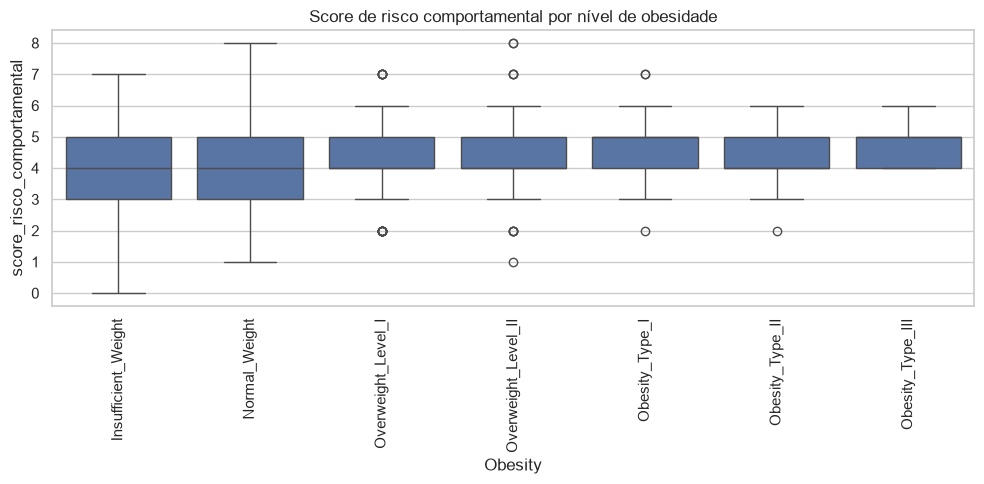

In [21]:
fig, eixo = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=pacientes_tratados, x="Obesity", y="score_risco_comportamental", order=ORDEM_NIVEIS_OBESIDADE, ax=eixo
)
eixo.set_title("Score de risco comportamental por nível de obesidade")
eixo.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

#### 7.2.3 `sedentarismo_score`

Diferença `TUE - FAF` (ambos já arredondados): valores positivos indicam mais tempo de tela relativo à atividade física; valores negativos indicam o oposto. Por construção, esta feature é combinação linear de duas variáveis já existentes no dataset — a multicolinearidade decorrente disso é avaliada na seção 7.3.

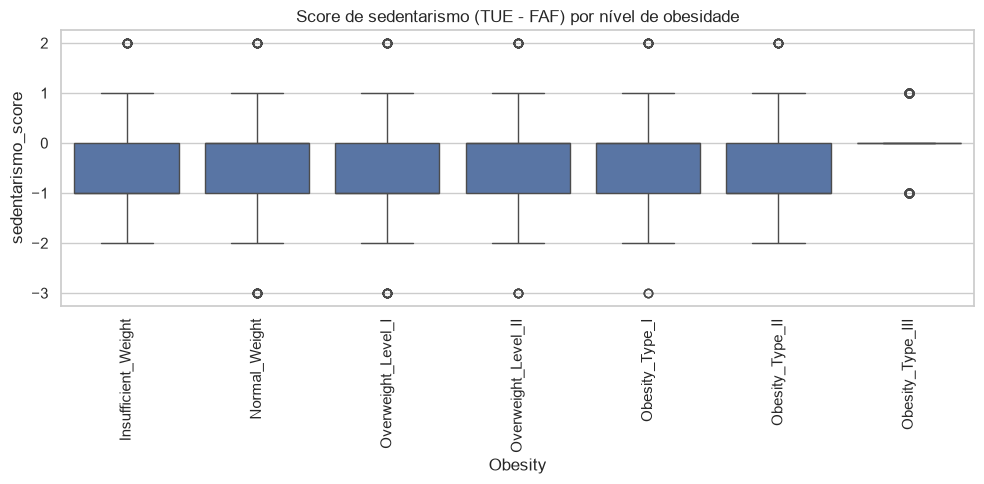

In [22]:
pacientes_tratados["sedentarismo_score"] = pacientes_tratados["TUE"] - pacientes_tratados["FAF"]

fig, eixo = plt.subplots(figsize=(10, 5))
sns.boxplot(data=pacientes_tratados, x="Obesity", y="sedentarismo_score", order=ORDEM_NIVEIS_OBESIDADE, ax=eixo)
eixo.set_title("Score de sedentarismo (TUE - FAF) por nível de obesidade")
eixo.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

#### 7.2.4 `interacao_historico_dieta`

Binária: 1 se o paciente tem histórico familiar de excesso de peso **e** consome alimentos calóricos com frequência (`family_history == "yes"` e `FAVC == "yes"`), 0 caso contrário. Captura o efeito combinado de predisposição genética/familiar com um hábito alimentar de risco.

In [23]:
pacientes_tratados["interacao_historico_dieta"] = (
    (pacientes_tratados["family_history"] == "yes") & (pacientes_tratados["FAVC"] == "yes")
).astype(int)

(
    pacientes_tratados.groupby("Obesity")["interacao_historico_dieta"].mean().reindex(ORDEM_NIVEIS_OBESIDADE) * 100
).rename("percentual_com_historico_e_dieta_de_risco")

Obesity
Insufficient_Weight    44.943820
Normal_Weight          38.652482
Overweight_Level_I     70.289855
Overweight_Level_II    71.034483
Obesity_Type_I         95.156695
Obesity_Type_II        97.643098
Obesity_Type_III       99.691358
Name: percentual_com_historico_e_dieta_de_risco, dtype: float64

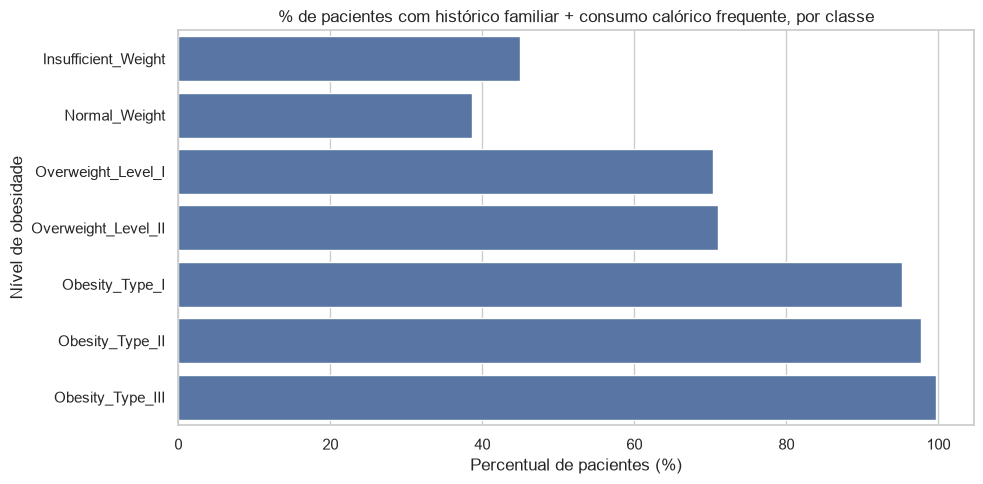

In [24]:
percentual_interacao_por_classe = (
    pacientes_tratados.groupby("Obesity")["interacao_historico_dieta"].mean().reindex(ORDEM_NIVEIS_OBESIDADE) * 100
)

fig, eixo = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=percentual_interacao_por_classe.values,
    y=percentual_interacao_por_classe.index,
    order=ORDEM_NIVEIS_OBESIDADE,
    ax=eixo,
)
eixo.set_title("% de pacientes com histórico familiar + consumo calórico frequente, por classe")
eixo.set_xlabel("Percentual de pacientes (%)")
eixo.set_ylabel("Nível de obesidade")
plt.tight_layout()
plt.show()

#### 7.2.5 `faixa_etaria`

Categorização clínica de `Age` em quatro faixas (`adolescente`, `adulto_jovem`, `adulto`, `meia_idade`). Não deve adicionar poder preditivo além do já capturado por `Age` contínua em modelos de árvore, mas facilita a leitura do perfil de pacientes para a equipe médica.

In [25]:
pacientes_tratados["faixa_etaria"] = pd.cut(
    pacientes_tratados["Age"],
    bins=[13, 19, 30, 45, 61],
    labels=["adolescente", "adulto_jovem", "adulto", "meia_idade"],
)

pacientes_tratados["faixa_etaria"].value_counts().reindex(
    ["adolescente", "adulto_jovem", "adulto", "meia_idade"]
)

faixa_etaria
adolescente      407
adulto_jovem    1324
adulto           342
meia_idade        14
Name: count, dtype: int64

### 7.3 Checagem de multicolinearidade das novas features numéricas

`score_risco_comportamental` e `sedentarismo_score` são, por construção, combinações de variáveis já presentes no dataset (incluindo `FAF` e `TUE`). Verificamos aqui o quanto isso se reflete em correlação, para decidir na modelagem se faz sentido usar a feature composta, os componentes originais, ou ambos com regularização.

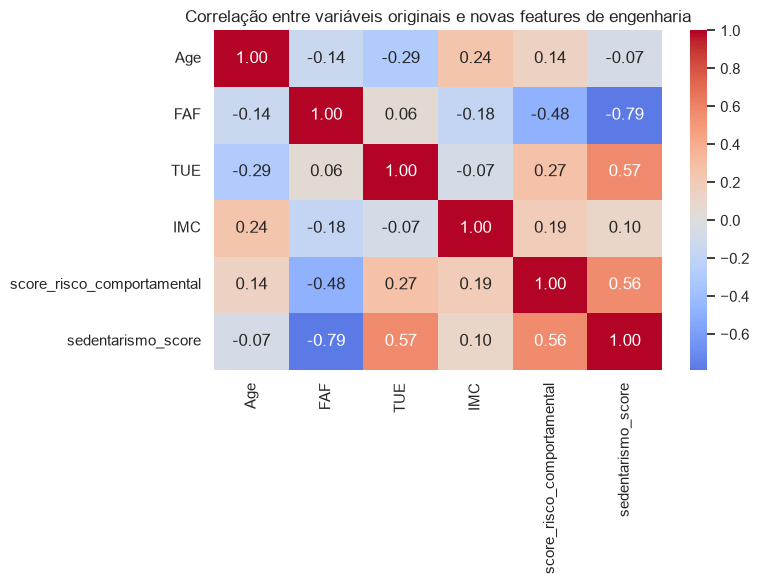

In [26]:
colunas_engenharia_numericas = ["Age", "FAF", "TUE", "IMC", "score_risco_comportamental", "sedentarismo_score"]

matriz_correlacao_engenharia = pacientes_tratados[colunas_engenharia_numericas].corr()

fig, eixo = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz_correlacao_engenharia, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=eixo)
eixo.set_title("Correlação entre variáveis originais e novas features de engenharia")
plt.tight_layout()
plt.show()

## 8. Modelagem

Fora do escopo deste notebook de EDA. O treinamento dos modelos (com `sklearn.Pipeline`/`ColumnTransformer`, testando múltiplos algoritmos com validação cruzada estratificada) será feito em um notebook dedicado de modelagem, reaproveitando os achados desta v2 — incluindo as novas features de 7.2 e a checagem de multicolinearidade de 7.3.

## 9. Avaliação

Fora do escopo deste notebook de EDA. As métricas de avaliação (accuracy, F1-macro, matriz de confusão, validação cruzada estratificada) serão reportadas no notebook de modelagem, conforme a metodologia do projeto.

## 10. Conclusões

**Qualidade dos dados**
- Não há valores nulos em nenhuma coluna.
- Há 24 linhas 100% duplicadas (~1,1% do dataset). Foram removidas em `pacientes_sem_duplicatas` como tratamento padrão de qualidade, ainda que plausíveis dado que parte deste dataset é sintética (gerada via SMOTE na fonte original).
- `FCVC`, `NCP`, `CH2O`, `FAF` e `TUE` chegam com ruído decimal no arquivo bruto, mesmo sendo escalas discretas pelo dicionário — foram arredondadas em `pacientes_tratados` antes de qualquer cruzamento, encoding, feature composta ou modelagem.

**Variável alvo**
- As 7 classes de `Obesity` têm contagens entre 272 (`Insufficient_Weight`) e 351 (`Obesity_Type_I`) pacientes — um desbalanceamento leve (razão ≈ 1,3x entre a maior e a menor classe), não severo. Ainda assim, split estratificado e métricas como F1-macro (além de accuracy) são recomendados na etapa de modelagem.

**Distribuições e correlações**
- `Age` é concentrada em adultos jovens (mediana ≈ 23 anos, faixa 14–61), com leve assimetria à direita. O único paciente com mais de 60 anos (61 anos) não foi tratado como outlier a remover: é um valor plausível (IMC coerente com `Normal_Weight`) e está no topo de uma cauda contínua, não isolado.
- `Height` e `Weight` têm distribuição aproximadamente contínua e sem outliers extremos aparentes; `FAF` e `TUE` têm massa concentrada perto de zero.
- Na matriz de correlação original, `Weight` é a variável mais correlacionada com `Height` (correlação moderada, ~0,46); as demais variáveis numéricas têm correlação fraca com `Weight`.

**Hábitos vs. nível de obesidade**
- `FAVC` (consumo frequente de alimentos calóricos = "yes") aparece proporcionalmente mais associado às classes de sobrepeso/obesidade mais altas.
- `MTRANS`: pacientes que usam `Automobile` concentram-se mais nas classes de obesidade mais altas, enquanto `Walking`/`Bike` aparecem mais entre `Insufficient_Weight`/`Normal_Weight`.
- `FCVC` e `FAF` (após arredondamento) mostram tendências visíveis nos boxplots por classe, mas com sobreposição considerável entre grupos.
- `CALC` tem categorias muito desbalanceadas (poucos casos em "Always"), o que deve ser considerado ao interpretar esse cruzamento.

**Achado central: o alvo é derivado de IMC**
- Ao calcular `IMC = Weight / Height²`, as faixas de IMC por classe de `Obesity` praticamente não se sobrepõem (ex.: `Insufficient_Weight` ≈ 13–19, `Normal_Weight` ≈ 18,5–24,9, `Obesity_Type_III` ≈ 36,8–50,8), confirmando que este dataset público (UCI *Estimation of obesity levels*) tem seu rótulo derivado diretamente de faixas de IMC.

**Novidade da v2 — features comportamentais compostas**
- `transporte_ativo` é o achado mais forte entre as novas features: cai de forma praticamente monotônica de ~12,4% em `Normal_Weight` para 0% em `Obesity_Type_III`. Sinal claro e de fácil leitura clínica.
- `interacao_historico_dieta` também mostra um gradiente muito forte: de ~39–45% nas classes mais leves para ~99,7% em `Obesity_Type_III`. É provavelmente a feature de hábito mais discriminativa do notebook (fora IMC), e mais informativa do que `family_history` ou `FAVC` isoladas.
- `score_risco_comportamental` tem uma tendência de aumento com a gravidade da obesidade, mas fraca (média varia de ~3,96 a ~4,58 num range de 0–9) — como é uma soma de vários fatores, alguns fortes (transporte, histórico+dieta) e outros fracos, o composto dilui o sinal dos componentes mais fortes. Vale testar na modelagem se ele agrega algo além de `transporte_ativo` e `interacao_historico_dieta` isoladas, ou se é redundante.
- `sedentarismo_score` (`TUE - FAF`) tem, como esperado por construção, correlação forte com seus componentes (`FAF` ≈ -0,79, `TUE` ≈ 0,57) — checar multicolinearidade antes de usar os três juntos em modelos lineares. A relação com o alvo é fraca e não monotônica, então não deve ser tratada como um substituto de `FAF`/`TUE` brutos.
- `faixa_etaria`: o grupo `meia_idade` tem apenas 14 pacientes — qualquer leitura sobre essa faixa deve considerar o tamanho amostral pequeno.

**Decisão sobre manter ou não `Height`/`Weight`/IMC no modelo — não é uma escolha neutra**

Como o alvo é essencialmente uma função determinística de `Height` e `Weight`, incluir essas duas colunas (ou qualquer derivada direta, como o próprio IMC) tende a produzir um modelo com accuracy muito alta, mas que apenas reaprendeu a fórmula do IMC — sem agregar valor clínico sobre hábitos alimentares e atividade física, que é o pedido de negócio do hospital. Substituir `Height`/`Weight` por IMC não resolve esse problema: pelo contrário, concentra a mesma informação circular em uma única variável ainda mais determinística.

Recomendação para o notebook de modelagem:
1. Treinar e documentar **dois modelos**: (a) um modelo de referência com `Height`/`Weight`/IMC, servindo de "teto" de performance e checagem de sanidade; e (b) um modelo de **hábitos e perfil**, sem `Height`, `Weight` ou IMC, usando as variáveis de hábito originais mais as novas features de 7.2 (com destaque para `transporte_ativo` e `interacao_historico_dieta`, os sinais mais fortes encontrados).
2. No modelo (b), avaliar formalmente (via importância de features e/ou VIF) se `score_risco_comportamental` e `sedentarismo_score` agregam poder preditivo além dos componentes que os formam, dado o grau de correlação observado em 7.3.
3. Deixar essa decisão e sua justificativa explícitas em markdown no notebook de modelagem, evitando apresentar a exclusão (ou inclusão) de `Height`/`Weight`/IMC como uma escolha técnica neutra.